# False positive and false negative review

**Purpose.** Both models disagree with the ICNF ground truth at a substantial
number of pixels even after the overlap vote and the minimum fire-size filter
(see `min_fire_size.ipynb`). This notebook examines those disagreements directly:
it recreates the reference agreement maps, ranks the connected false positive
(FP) and false negative (FN) components for each model, crops the largest ones
for a closer look, and checks a sample against real Sentinel-2 imagery fetched
from the Copernicus Data Space Ecosystem (CDSE).

**Dataset.** The 50% overlap burned-area vote maps of tile T29TPG for both
Swin-YNet and EfficientNet-B2 (before 2025-07-07, after 2025-10-15), thresholded
at a 75 percent vote and a 100-pixel minimum fire size, scored against the ICNF
fire records filtered to the date window and clipped to Portugal. This is the
same setting as the reference figure under review.

**Objectives.** (1) Recreate the reference agreement maps as a sanity check;
(2) tabulate and rank the largest FP and FN connected components per model;
(3) crop and visually compare the standout clusters against the vote map and
ground truth; (4) verify a sample against real Sentinel-2 true colour imagery;
(5) discuss the likely causes of the largest disagreements.


## 1. Setup and data

Loads the vote maps and labels the burned patches once, exactly as in
`min_fire_size.ipynb`, then builds the date-windowed, eroded ground truth.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import rasterio
from rasterio.features import rasterize
from rasterio.warp import transform_bounds
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from scipy.ndimage import label as ndlabel

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 140, "font.size": 11,
    "axes.titlesize": 12, "axes.titleweight": "medium",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})
MODEL_COLOR = {"swin_ynet": "#4477aa", "efficientnet_b2": "#cc6677"}
MODEL_LABEL = {"swin_ynet": "Swin-YNet", "efficientnet_b2": "EfficientNet-B2"}
C_AGREE, C_FALSE, C_MISS = "#762a83", "#d6604d", "#2c7bb6"

for _c in (Path.cwd(), Path.cwd().parent):
    if (_c / "utils" / "config.py").exists():
        sys.path.insert(0, str(_c)); break
from utils.config import load_config
from utils.sentinel_hub import fetch_truecolor, CDSEAuthError

cfg = load_config()


In [2]:
BEFORE, AFTER = "2025-07-07", "2025-10-15"
B, A = BEFORE.replace("-", ""), AFTER.replace("-", "")
PRED = cfg.predictions_dir
LABELS = cfg.repo_root / "data/processed/icnf_burned_labels_t29tpg_2025.tif"
ICNF_SHP = cfg.repo_root / "data/shapefiles/ground_truth_ICNF/ardida_2025.shp"
PT_BOUND = cfg.repo_root / "data/shapefiles/boundary_files/portugal_continental_32629.gpkg"
PIX_HA = 0.01
MODELS = ["efficientnet_b2", "swin_ynet"]
OVERLAP = 50
VOTE_PCT = 75
MIN_SIZE = 100        # reference setting under review
SHOW_SIZES = [25, 100, 200]

def read(p):
    with rasterio.open(p) as r:
        return r.read(1)

def votes_path(mdl):
    return PRED / f"T29TPG_{mdl}_ov{OVERLAP:02d}_{B}_{A}_votes.tif"

def observed_path(mdl):
    return PRED / f"T29TPG_{mdl}_ov{OVERLAP:02d}_{B}_{A}_observed.tif"

labels_img = read(LABELS)
with rasterio.open(LABELS) as r:
    GRID_T, GRID_SHAPE = r.transform, (r.height, r.width)
    EXTENT = (r.bounds.left, r.bounds.right, r.bounds.bottom, r.bounds.top)

PT = gpd.read_file(PT_BOUND).to_crs("EPSG:32629")
inside_pt = rasterize([(g, 1) for g in PT.geometry], out_shape=GRID_SHAPE,
                       transform=GRID_T, fill=0, dtype="uint8").astype(bool)
comp = (read(observed_path(MODELS[0])) == 1) & inside_pt & (labels_img != 255)

# Patches labelled once per model at every minimum size we plot.
votes = {mdl: read(votes_path(mdl)) for mdl in MODELS}
burned_at = {mdl: (votes[mdl] != 255) & (votes[mdl] >= VOTE_PCT) for mdl in MODELS}
patches = {}
for mdl in MODELS:
    lab, n = ndlabel(burned_at[mdl])
    sizes = np.bincount(lab.ravel())
    patches[mdl] = (lab, sizes)
    print(f"{MODEL_LABEL[mdl]}: {n:,} connected burned patches at {VOTE_PCT}% vote")


EfficientNet-B2: 5,684 connected burned patches at 75% vote
Swin-YNet: 2,177 connected burned patches at 75% vote


In [3]:
fires = gpd.read_file(ICNF_SHP).to_crs("EPSG:32629")
fires = fires.cx[EXTENT[0]:EXTENT[1], EXTENT[2]:EXTENT[3]].copy()
fires["s"] = pd.to_datetime(fires["DH_Inicio"])
fires["e"] = pd.to_datetime(fires["DH_Fim"])
sel = fires[(fires["s"] >= pd.Timestamp(BEFORE)) & (fires["e"] <= pd.Timestamp(AFTER))]
geoms = [g for g in sel.geometry.buffer(-10) if not g.is_empty]
truth = rasterize([(g, 1) for g in geoms], out_shape=GRID_SHAPE,
                   transform=GRID_T, fill=0, dtype="uint8").astype(bool)
t = truth & comp
print(f"ground-truth fire in window: {t.sum() * PIX_HA:,.0f} ha")

def filtered_pred(mdl, min_size):
    lab, sizes = patches[mdl]
    keep = sizes >= min_size
    keep[0] = False
    return keep[lab] & comp


ground-truth fire in window: 10,636 ha


## 2. Recreating the reference agreement maps

**Objective.** Recreate the three-panel TP/FP/FN agreement maps at minimum
fire sizes of 25, 100 and 200 pixels, for both models, at 50% overlap and a
75 percent vote. The standout false-positive region discussed in this notebook
is marked with a box on the 100-pixel panel.


In [4]:
def pool_or(a, k=12):
    H, W = (a.shape[0] // k) * k, (a.shape[1] // k) * k
    return a[:H, :W].reshape(H // k, k, W // k, k).max(axis=(1, 3))

def confusion_rgb(mdl, min_size):
    p = filtered_pred(mdl, min_size)
    TP, FP, FN = pool_or(p & t), pool_or(p & ~t), pool_or(~p & t)
    img = np.ones(TP.shape + (3,))
    for m, c in [(FN, C_MISS), (FP, C_FALSE), (TP, C_AGREE)]:
        img[m] = mcolors.to_rgb(c)
    return img


In [5]:
# Largest FP/FN connected components per model, at the reference setting
# (75% vote, 100 px minimum) — used for the box below and ranked in Section 3.
def top_components(mask, k=5):
    lab, n = ndlabel(mask)
    sizes = np.bincount(lab.ravel())
    sizes[0] = 0
    order = np.argsort(sizes)[::-1][:k]
    out = []
    for cid in order:
        if sizes[cid] == 0:
            continue
        rows, cols = np.where(lab == cid)
        r0, r1, c0, c1 = rows.min(), rows.max() + 1, cols.min(), cols.max() + 1
        left, top_ = GRID_T * (c0, r0)
        right, bottom = GRID_T * (c1, r1)
        lon0, lat0, lon1, lat1 = transform_bounds("EPSG:32629", "EPSG:4326", left, bottom, right, top_)
        out.append(dict(id=int(cid), px=int(sizes[cid]), ha=sizes[cid] * PIX_HA,
                         utm_bbox=(left, bottom, right, top_), wgs84_bbox=(lon0, lat0, lon1, lat1)))
    return out

pred_swin = filtered_pred("swin_ynet", MIN_SIZE)
fp_swin = pred_swin & ~t
swin_fp_top = top_components(fp_swin, k=1)[0]
print("standout cluster (Swin-YNet FP, 100 px):", swin_fp_top)


standout cluster (Swin-YNet FP, 100 px): {'id': 2518, 'px': 61426, 'ha': 614.26, 'utm_bbox': (694560.0, 4591640.0, 701100.0, 4595520.0), 'wgs84_bbox': (-6.670672770178178, 41.45116103025374, -6.5911464278080825, 41.487692766951845)}


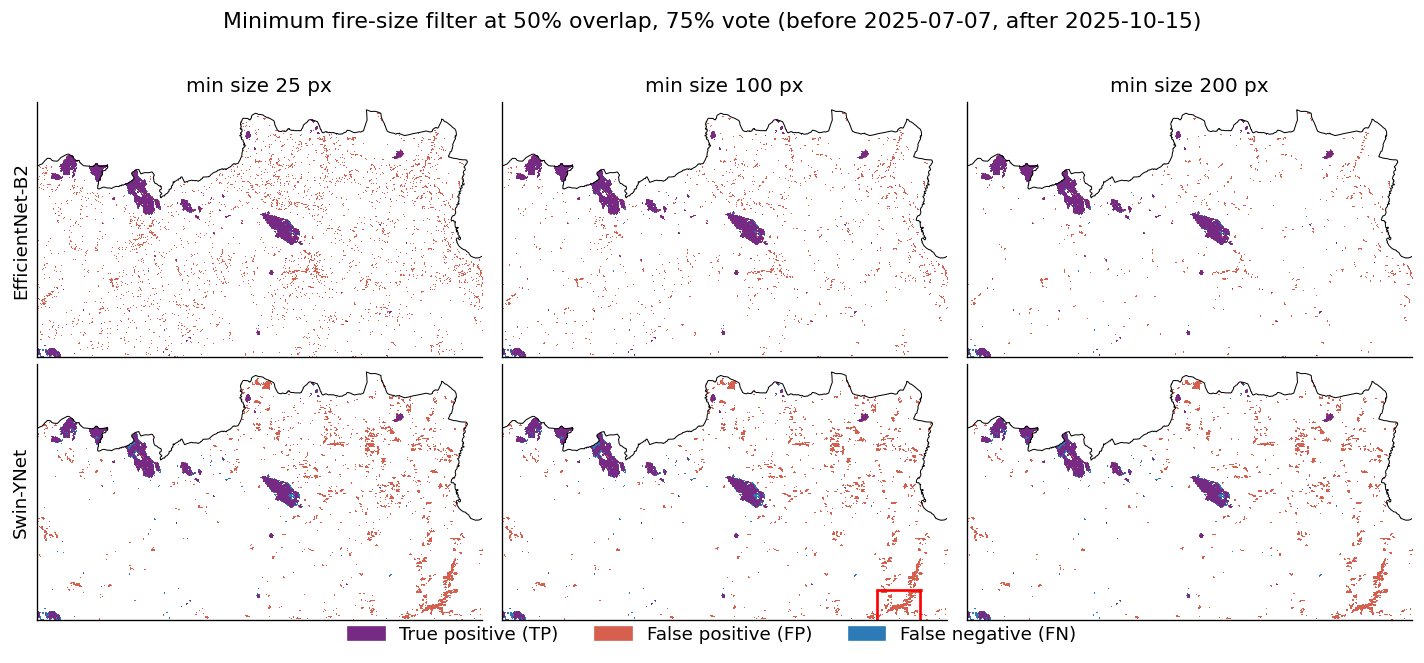

In [6]:
fig, axes = plt.subplots(len(MODELS), len(SHOW_SIZES), figsize=(4 * len(SHOW_SIZES), 2.6 * len(MODELS)))
axes = np.atleast_2d(axes)
for i, mdl in enumerate(MODELS):
    for j, ms in enumerate(SHOW_SIZES):
        ax = axes[i, j]
        ax.imshow(confusion_rgb(mdl, ms), extent=EXTENT, origin="upper", interpolation="nearest")
        PT.boundary.plot(ax=ax, color="black", linewidth=0.6)
        ax.set_xlim(EXTENT[0], EXTENT[1]); ax.set_ylim(EXTENT[2], EXTENT[3])
        ax.set_xticks([]); ax.set_yticks([])
        if i == 0:
            ax.set_title(f"min size {ms} px")
        if j == 0:
            ax.set_ylabel(MODEL_LABEL[mdl])
        if mdl == "swin_ynet" and ms == 100:
            l, b, r, top_ = swin_fp_top["utm_bbox"]
            pad = 2000
            rect = mpatches.Rectangle((l - pad, b - pad), (r - l) + 2 * pad, (top_ - b) + 2 * pad,
                                       fill=False, edgecolor="red", linewidth=1.6)
            ax.add_patch(rect)

handles = [mpatches.Patch(color=C_AGREE, label="True positive (TP)"),
           mpatches.Patch(color=C_FALSE, label="False positive (FP)"),
           mpatches.Patch(color=C_MISS, label="False negative (FN)")]
fig.legend(handles=handles, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Minimum fire-size filter at 50% overlap, 75% vote "
             f"(before {BEFORE}, after {AFTER})", y=1.02)
plt.tight_layout()
plt.show()


*Observation.* The pattern matches `min_fire_size.ipynb`: EfficientNet-B2's
false positives are scattered specks that thin out steadily as the minimum
size rises from 25 to 200 pixels. Swin-YNet keeps a large false-positive
region near the southern edge of the tile (boxed) across every minimum size
shown, since the region is far above the 200-pixel cutoff and the size
filter cannot reach it. At this zoom the region already reads as elongated
and branching rather than a compact blob, which Section 4 examines more
closely. Section 3 ranks every cluster first, to confirm this is the largest
disagreement either model produces at this setting.


## 3. Ranking the largest error clusters

**Objective.** Tabulate and rank the connected FP and FN components for both
models at the reference setting (75% vote, 100-pixel minimum), to confirm
which disagreements are worth a closer look and which are comparatively
minor speckle.


In [7]:
rows = []
for mdl in MODELS:
    p = filtered_pred(mdl, MIN_SIZE)
    fp, fn = p & ~t, ~p & t
    for kind, mask in [("FP", fp), ("FN", fn)]:
        for c in top_components(mask, k=3):
            rows.append({"model": MODEL_LABEL[mdl], "type": kind, "area_ha": round(c["ha"], 1),
                         "area_px": c["px"], "lon_min": round(c["wgs84_bbox"][0], 4),
                         "lat_min": round(c["wgs84_bbox"][1], 4), "lon_max": round(c["wgs84_bbox"][2], 4),
                         "lat_max": round(c["wgs84_bbox"][3], 4)})
cluster_table = pd.DataFrame(rows).sort_values(["type", "area_ha"], ascending=[True, False]).reset_index(drop=True)
cluster_table


,model,type,area_ha,area_px,lon_min,lat_min,lon_max,lat_max
0,Swin-YNet,FN,100.2,10020,-7.5174,41.8373,-7.5023,41.8525
1,Swin-YNet,FN,84.6,8455,-7.7520,41.4568,-7.7328,41.4655
2,Swin-YNet,FN,70.6,7064,-7.7791,41.4616,-7.7678,41.4749
3,EfficientNet-B2,FN,45.1,4514,-7.7519,41.4569,-7.7408,41.4659
4,EfficientNet-B2,FN,45.1,4510,-7.8027,41.4573,-7.7861,41.4680
5,EfficientNet-B2,FN,43.2,4317,-7.0526,41.7342,-7.0363,41.7478
6,Swin-YNet,FP,614.3,61426,-6.6707,41.4512,-6.5911,41.4877
7,Swin-YNet,FP,294.8,29480,-6.6063,41.4835,-6.5594,41.5085
8,Swin-YNet,FP,246.1,24607,-6.6042,41.5287,-6.5691,41.5567
9,EfficientNet-B2,FP,35.7,3566,-6.5509,41.6159,-6.5311,41.6304


*Observation.* Swin-YNet's largest false positive (614 ha) is more than twice
the size of its next-largest cluster and over an order of magnitude larger
than any cluster either model produces elsewhere in the table. Every other FP
and FN cluster for both models, including all of EfficientNet's, falls under
50 ha, consistent with isolated misclassification rather than a single
systematic failure. This is why the standout cluster, rather than any of the
smaller ones, is the focus of the closer look and the Sentinel-2 check below.


## 4. Close-up review of the standout clusters

**Objective.** Crop the vote map and the ground truth around the standout
Swin-YNet false positive, and around one representative EfficientNet false
positive and one representative false negative, for a closer look at what
each model saw before disagreeing with the ground truth.


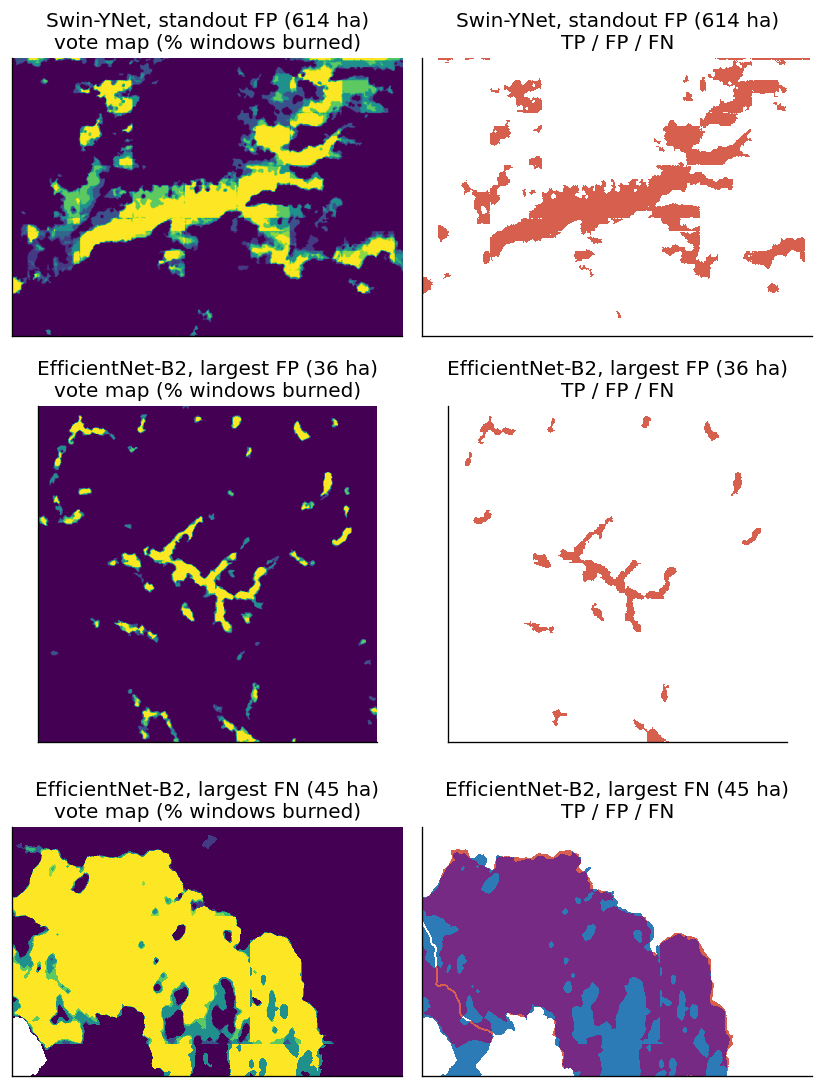

In [8]:
def crop_window(bbox, pad=1500):
    left, bottom, right, top_ = bbox
    left, bottom, right, top_ = left - pad, bottom - pad, right + pad, top_ + pad
    r0, c0 = rasterio.transform.rowcol(GRID_T, left, top_)
    r1, c1 = rasterio.transform.rowcol(GRID_T, right, bottom)
    r0, r1 = max(0, r0), min(GRID_SHAPE[0], r1)
    c0, c1 = max(0, c0), min(GRID_SHAPE[1], c1)
    return r0, r1, c0, c1

def show_cluster(mdl, bbox, label, ax_row):
    r0, r1, c0, c1 = crop_window(bbox)
    v = votes[mdl][r0:r1, c0:c1]
    gt = t[r0:r1, c0:c1]
    p = filtered_pred(mdl, MIN_SIZE)[r0:r1, c0:c1]
    cat = np.zeros(v.shape + (3,))
    cat[:] = mcolors.to_rgb("white")
    cat[p & gt] = mcolors.to_rgb(C_AGREE)
    cat[p & ~gt] = mcolors.to_rgb(C_FALSE)
    cat[~p & gt] = mcolors.to_rgb(C_MISS)

    ax_row[0].imshow(np.where(v == 255, np.nan, v), cmap="viridis", vmin=0, vmax=100)
    ax_row[0].set_title(f"{label}\nvote map (% windows burned)")
    ax_row[1].imshow(cat, interpolation="nearest")
    ax_row[1].set_title(f"{label}\nTP / FP / FN")
    for ax in ax_row:
        ax.set_xticks([]); ax.set_yticks([])

clusters_to_show = [
    ("swin_ynet", swin_fp_top["utm_bbox"], "Swin-YNet, standout FP (614 ha)"),
]
efn_p = filtered_pred("efficientnet_b2", MIN_SIZE)
efn_fp1 = top_components(efn_p & ~t, k=1)[0]
efn_fn1 = top_components(~efn_p & t, k=1)[0]
clusters_to_show.append(("efficientnet_b2", efn_fp1["utm_bbox"], f"EfficientNet-B2, largest FP ({efn_fp1['ha']:.0f} ha)"))
clusters_to_show.append(("efficientnet_b2", efn_fn1["utm_bbox"], f"EfficientNet-B2, largest FN ({efn_fn1['ha']:.0f} ha)"))

fig, axes = plt.subplots(len(clusters_to_show), 2, figsize=(7, 3.2 * len(clusters_to_show)))
axes = np.atleast_2d(axes)
for row, (mdl, bbox, label) in zip(axes, clusters_to_show):
    show_cluster(mdl, bbox, label, row)
plt.tight_layout()
plt.show()


*Observation.* The standout Swin-YNet cluster votes burned at a high,
spatially coherent percentage along a narrow, winding, branching shape, not
a compact blob. That shape is consistent with a river channel or stream
network rather than a fire scar or a forestry clearance, both of which would
follow terrain or field boundaries and read as more compact and rounded. A
plausible explanation is that the model is reacting to water, exposed
sediment, or a seasonal water-level change along this drainage line, rather
than to fire. The EfficientNet examples are smaller and more textured, with
the vote percentage varying within each crop, consistent with scattered
per-window disagreement at field- or patch-scale boundaries rather than one
coherent change. The largest EfficientNet false negative also shows a
genuine fire only partly detected (true positive over part of the burned
patch, false negative over the rest), pointing to under-detection at the
margins of a real fire rather than a missed detection of the whole event.
The river hypothesis for the Swin-YNet cluster is testable directly: Section
5 checks it against real Sentinel-2 imagery.


## 5. Verification against real Sentinel-2 imagery

**Purpose.** Pull true colour Sentinel-2 chips for the standout cluster, one
from around the before date and one from around the after date, via the CDSE
Process API (`utils/sentinel_hub.py`), to check by eye whether the flagged
area shows a real, visible change.

**Requires CDSE OAuth credentials.** Do not paste real credentials into a
cell in this notebook: it is tracked by git and pushed to GitHub, so anything
typed here is committed in plain text. Instead, add a `cdse:` block with your
real `client_id`/`client_secret` to `config.local.yaml` at the repo root
(already in `.gitignore`, never committed), or export
`CDSE_CLIENT_ID`/`CDSE_CLIENT_SECRET` as environment variables in your shell
before launching Jupyter. `fetch_truecolor` reads both automatically; no
notebook cell needs to set them. See the `utils/sentinel_hub.py` module
docstring for how to register an OAuth client and where to find the secret
(shown once, at creation time, not your CDSE account password). Without
credentials available either way, the cell below raises a `CDSEAuthError`
with these same setup instructions instead of producing images.


In [9]:
from utils.sentinel_hub import _get_token, CDSEAuthError
try:
    _tok = _get_token()
    print(f"CDSE auth OK, token length {len(_tok)}")
except CDSEAuthError as e:
    print(f"CDSE auth FAILED: {e}")


CDSE auth OK, token length 1590


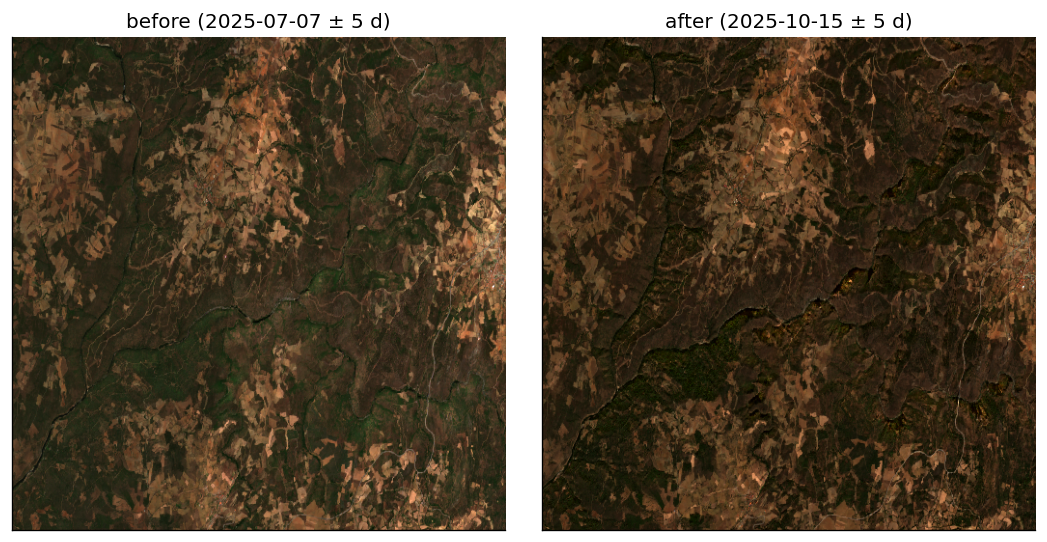

In [10]:
target_bbox = swin_fp_top["utm_bbox"]
pad = 1500
bbox_padded = (target_bbox[0] - pad, target_bbox[1] - pad, target_bbox[2] + pad, target_bbox[3] + pad)

try:
    img_before = fetch_truecolor(bbox_padded, BEFORE, bbox_crs="EPSG:32629")
    img_after = fetch_truecolor(bbox_padded, AFTER, bbox_crs="EPSG:32629")
    fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
    axes[0].imshow(img_before); axes[0].set_title(f"before ({BEFORE} ± 5 d)")
    axes[1].imshow(img_after); axes[1].set_title(f"after ({AFTER} ± 5 d)")
    for ax in axes:
        ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout()
    plt.show()
except CDSEAuthError as e:
    print(e)


*Observation.* Confirmed against the true colour chips: the flagged region
is a river channel running through a valley, flanked by agricultural plots on
both sides, consistent with the narrow, winding, branching shape identified
in Section 4. The channel and its valley floor look essentially unchanged
between the before and after image, no darkening, no loss of vegetation, no
burn-scar texture, while the agricultural parcels alongside it show their own
independent tonal changes consistent with normal land management rather than
fire. This rules out a genuine fire event at this location and confirms the
river hypothesis: the 614 ha cluster is a real, persistent landscape feature
that Swin-YNet has misread as burned, not a fire ICNF failed to record.

### EfficientNet-B2: the narrow branching cluster beneath the large ICNF fire

**Purpose.** Section 3's ranking surfaces EfficientNet-B2's three largest false
positives, all under 50 ha (Section 3), but the reference agreement map
(Section 2) also shows smaller clusters near the tile's large fires that read
as narrow and forked rather than compact, the same shape signature used above
for the Swin-YNet river. The cell below ranks EfficientNet's ten largest FP
clusters by fill ratio (area over bounding-box area, as used in Section 4)
and checks which of the narrow ones sits directly beneath a large ICNF fire,
to single out a candidate worth the same Sentinel-2 check.

In [14]:
def bbox_to_rowcol(utm_bbox):
    left, bottom, right, top_ = utm_bbox
    r0, c0 = rasterio.transform.rowcol(GRID_T, left, top_)
    r1, c1 = rasterio.transform.rowcol(GRID_T, right, bottom)
    return r0, r1, c0, c1

def fill_ratio(c):
    r0, r1, c0, c1 = bbox_to_rowcol(c["utm_bbox"])
    return c["px"] / ((r1 - r0) * (c1 - c0))

def gap_below_large_fire(c, large_gt, max_col_gap=500):
    """Pixel gap to the nearest large (>500 ha) ICNF fire directly above c,
    requiring near column overlap; None if no large fire sits above it."""
    fr0, fr1, fc0, fc1 = bbox_to_rowcol(c["utm_bbox"])
    best = None
    for gt in large_gt:
        gr0, gr1, gc0, gc1 = bbox_to_rowcol(gt["utm_bbox"])
        col_gap = max(0, fc0 - gc1, gc0 - fc1)
        row_gap = fr0 - gr1
        if row_gap > 0 and col_gap < max_col_gap:
            d = row_gap + col_gap
            if best is None or d < best:
                best = d
    return best

efn_fp_top10 = top_components(efn_p & ~t, k=10)
gt_top10 = top_components(t, k=10)              # raw ICNF fire extent, model-independent
large_gt = [c for c in gt_top10 if c["ha"] > 500]

shape_table = pd.DataFrame([
    {"id": c["id"], "area_ha": round(c["ha"], 1), "fill_ratio": round(fill_ratio(c), 2),
     "gap_below_large_fire_px": gap_below_large_fire(c, large_gt)}
    for c in efn_fp_top10
]).sort_values("fill_ratio")
shape_table

,id,area_ha,fill_ratio,gap_below_large_fire_px
0,3242,35.7,0.14,NaN
7,1522,17.2,0.14,NaN
9,3467,15.3,0.14,NaN
2,3278,24.3,0.19,NaN
1,137,25.9,0.22,NaN
4,3231,20.1,0.26,728.0
5,239,18.3,0.27,NaN
3,318,20.6,0.43,NaN
8,2805,15.5,0.49,NaN
6,3353,18.2,0.51,1893.0


In [15]:
# Among the narrow candidates (fill ratio < 0.3), keep the one that sits
# beneath a large ICNF fire rather than off on its own.
efn_branch = next(c for c in efn_fp_top10
                  if fill_ratio(c) < 0.3 and gap_below_large_fire(c, large_gt) is not None)
print(f"selected cluster: id {efn_branch['id']}, {efn_branch['ha']:.1f} ha, "
      f"fill ratio {fill_ratio(efn_branch):.2f}")

selected cluster: id 3231, 20.1 ha, fill ratio 0.26


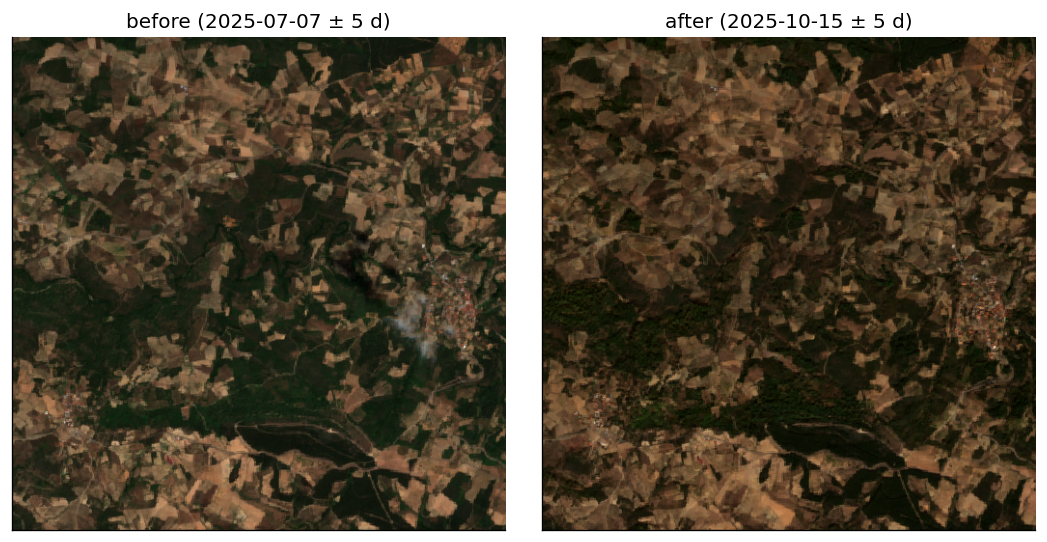

In [13]:
target_bbox = efn_branch["utm_bbox"]
pad = 1500
bbox_padded = (target_bbox[0] - pad, target_bbox[1] - pad, target_bbox[2] + pad, target_bbox[3] + pad)

try:
    img_before = fetch_truecolor(bbox_padded, BEFORE, bbox_crs="EPSG:32629")
    img_after = fetch_truecolor(bbox_padded, AFTER, bbox_crs="EPSG:32629")
    fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
    axes[0].imshow(img_before); axes[0].set_title(f"before ({BEFORE} \u00b1 5 d)")
    axes[1].imshow(img_after); axes[1].set_title(f"after ({AFTER} \u00b1 5 d)")
    for ax in axes:
        ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout()
    plt.show()
except CDSEAuthError as e:
    print(e)

In [ ]:
# Overlay the flagged false-positive pixels on the true colour chips, to see
# exactly which part of the scene EfficientNet-B2 voted burned, rather than
# guessing from the bounding box alone.
r0, r1, c0, c1 = crop_window(efn_branch["utm_bbox"])
fp_crop = (efn_p & ~t)[r0:r1, c0:c1]
crop_extent = (bbox_padded[0], bbox_padded[2], bbox_padded[1], bbox_padded[3])

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
for ax, img, title in zip(axes, [img_before, img_after],
                          [f"before ({BEFORE} \u00b1 5 d)", f"after ({AFTER} \u00b1 5 d)"]):
    ax.imshow(img, extent=crop_extent, origin="upper")
    ax.imshow(np.where(fp_crop, 1, np.nan), extent=crop_extent, origin="upper",
              cmap=mcolors.ListedColormap([C_FALSE]), vmin=0, vmax=1, alpha=0.45)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

*Observation.* Confirmed against an OpenStreetMap hydrology layer for the
same coordinates: this is a stream network, not a road. Google Maps' default
satellite/road view (which only renders OSM's tagged roads and tracks) showed
a dashed track crossing the area and no blue water symbol, which is why the
first pass misread this as a forest track; OSM's dedicated waterway layer
resolves the same spot to a confluence of three mapped streams (Regato do
Azibal, Regato do gricho and a tributary of Ribeiro de Ferreira). The
flagged false-positive pixels in the overlay above trace a branching,
forking shape that matches this confluence far better than a single track
would, multiple narrow channels converging toward one point, mirroring the
dendritic pattern rather than a single line. The chips themselves are
visually unchanged between the before and after image along the flagged
channel, no darkening, no vegetation loss, no burn-scar texture. Taken
together, this is the same failure mode identified for Swin-YNet in Section
5 at smaller scale: a real, persistent watercourse misread as fire, not an
event ICNF failed to record. The lesson for Google Maps vs. OpenStreetMap as
a verification tool generalises beyond this one cluster: OSM's explicit
waterway tagging is the more reliable free cross-check for any future
candidate, Google's default layer under-represents minor streams.

## 6. Summary

EfficientNet-B2 and Swin-YNet fail in different ways at this setting (50%
overlap, 75% vote, 100-pixel minimum fire size). EfficientNet's disagreements
are small, scattered clusters, all under 50 ha, spread across the tile and
varying in vote percentage within each cluster. This pattern is consistent
with ordinary per-window classification noise at field or patch boundaries
rather than a systematic blind spot, and matches why the minimum-size filter
in `min_fire_size.ipynb` is so effective for this model: raising the cutoff
removes speckle without touching real fires.

Swin-YNet's error budget is dominated by one 614 ha false-positive region that
is more than twice the size of its next-largest cluster and well above even
the strictest 200-pixel cutoff tested, so no minimum-size filter in the range
considered removes it. Its high vote percentage, combined with its narrow,
winding, branching shape rather than a compact blob, pointed away from a
classification artefact and toward a real, contiguous feature in the input
scenes that follows a drainage line. The true colour comparison in Section 5
confirms this: the flagged region is a river channel running through a
valley, bordered by agricultural land, unchanged in appearance between the
before and after image. This is a genuine model weakness rather than a
labelling gap. Swin-YNet appears to misread the combination of dark water or
exposed sediment in the channel and the surrounding cleared or tilled
agricultural land, both of which can share spectral characteristics with a
burn scar, as a single large fire. Because the false positive sits well above
the largest minimum-size cutoff considered, removing it requires either
retraining with more river-valley and agricultural-land examples in
non-fire epochs, or a post-hoc rule that flags large, narrow, branching
clusters for manual review before they reach a burned-area product.
EfficientNet's largest false negative, by contrast, is a real fire detected
over only part of its extent, suggesting the model's boundary delineation is
conservative rather than blind to the event.

One exception to the noise pattern above is worth flagging: the 20 ha
cluster examined in Section 5 (id 3231) is not ordinary speckle but the same
watercourse-misread-as-fire failure identified for Swin-YNet, at a stream
confluence rather than a single river channel. It is small enough that it
does not change the overall characterisation of EfficientNet's errors as
predominantly noise, but it shows the failure mode is not unique to
Swin-YNet, only rarer and smaller in EfficientNet's output at this
setting.